# Solución en multiples posiciones

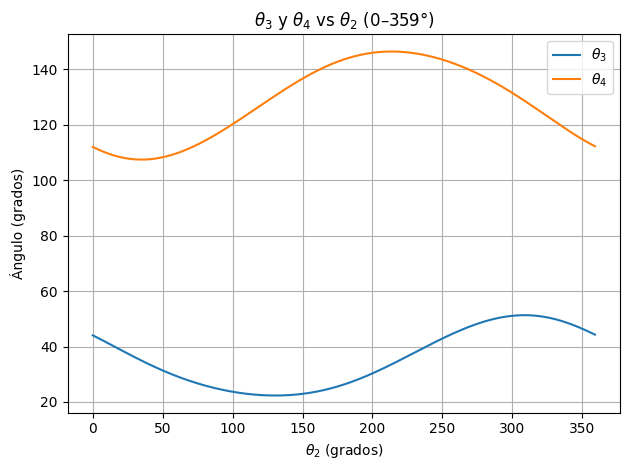

Convergió en 360 de 360 ángulos.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

def fourbar_eqs(x, L1, L2, L3, L4, theta2):
    theta3, theta4 = x
    F1 = L2*np.cos(theta2) + L3*np.cos(theta3) - L4*np.cos(theta4) - L1
    F2 = L2*np.sin(theta2) + L3*np.sin(theta3) - L4*np.sin(theta4)
    return np.array([F1, F2], dtype=float)

# Parámetros
L1, L2, L3, L4 = 100.0, 20.0, 80.0, 60.0

theta2_deg_vals = np.arange(0, 360, 1)
theta3_rad_vals = np.full(theta2_deg_vals.shape, np.nan, dtype=float)
theta4_rad_vals = np.full(theta2_deg_vals.shape, np.nan, dtype=float)
converged = np.zeros(theta2_deg_vals.shape, dtype=bool)

# Semilla inicial (en radianes)
x0 = np.deg2rad([30.0, 90.0])

for i, th2_deg in enumerate(theta2_deg_vals):
    th2 = np.deg2rad(float(th2_deg))

    sol, info, ier, msg = fsolve(
        fourbar_eqs, x0, args=(L1, L2, L3, L4, th2),
        full_output=True, xtol=1e-10, maxfev=200
    )

    if ier == 1 and np.isfinite(sol).all():
        theta3_rad_vals[i], theta4_rad_vals[i] = sol
        converged[i] = True
        # Usar la solución actual como semilla del siguiente ángulo (seguimiento de rama)
        x0 = sol

# Convertir (y “desenrollar” para evitar saltos de 360°)
theta3_deg = np.rad2deg(np.unwrap(theta3_rad_vals))
theta4_deg = np.rad2deg(np.unwrap(theta4_rad_vals))

# Gráfica
plt.figure()
plt.plot(theta2_deg_vals, theta3_deg, label=r'$\theta_3$')
plt.plot(theta2_deg_vals, theta4_deg, label=r'$\theta_4$')
plt.xlabel(r'$\theta_2$ (grados)')
plt.ylabel('Ángulo (grados)')
plt.title(r'$\theta_3$ y $\theta_4$ vs $\theta_2$ (0–359°)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Convergió en {converged.sum()} de {len(converged)} ángulos.")
if (~converged).any():
    print("Ejemplos de θ2 donde falló:", theta2_deg_vals[~converged][:10])